In [18]:
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np

In [19]:
video = cv.VideoCapture('./videos/Bris.mp4')

In [20]:
ret, or_frame = video.read()

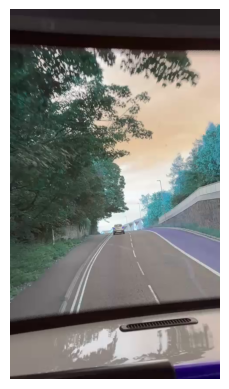

In [21]:
plt.imshow(or_frame)
plt.axis('off');

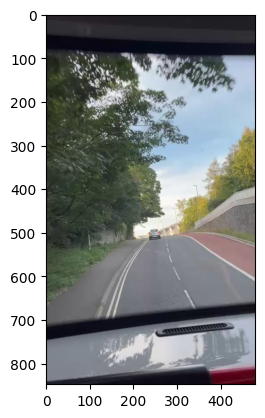

In [22]:
# view original frame as in the video
rgb_frame = cv.cvtColor(or_frame, cv.COLOR_BGR2RGB)
plt.imshow(rgb_frame);

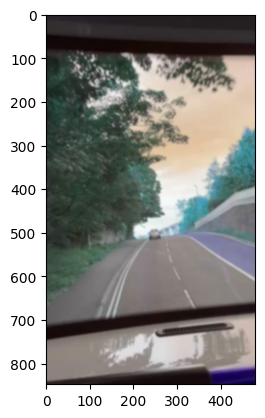

In [23]:
blurry_frame = cv.GaussianBlur(or_frame, (9,9), 0)
plt.imshow(blurry_frame);

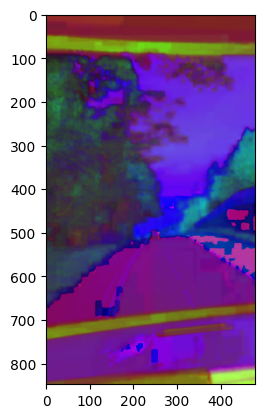

In [24]:
hsv = cv.cvtColor(blurry_frame, cv.COLOR_BGR2HSV)
plt.imshow(hsv);

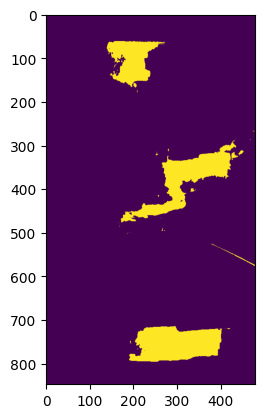

In [30]:
# color mask: detect only yellow
lower_w = np.array([0, 0, 200])
upper_w = np.array([180, 30, 255])
mask=cv.inRange(hsv,lower_w,upper_w)
plt.imshow(mask);

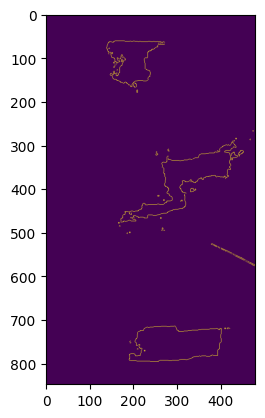

In [31]:
# canny edge detection: if the intensity gradient of pixel is greater than the higher threshold, it will be added as an edge pixel. 
# If the pixel's intensity gradient value is lower than the lower threshold it will be ignored.
#  and if intensity gradient is  between lower and higher threshold it will only be added as an edge if it is connected to any having the value larger than the higher threshold.
edges = cv.Canny(mask, 74 , 150) 
plt.imshow(edges);

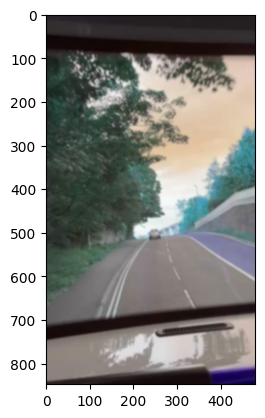

In [27]:
# Hough transform to detect lines
lines=cv.HoughLinesP(edges,1,np.pi/180,50,maxLineGap=50)
if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv.line(blurry_frame,(x1,y1),(x2,y2),(0,255,0),5)

plt.imshow(blurry_frame);   

In [32]:
def get_roi_mask(shape):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    polygon = np.array([[
        (80,  720),   # bottom-left
        (380, 720),   # bottom-right
        (260, 510),   # top-right (narrow at horizon)
        (190, 510),   # top-left
    ]], np.int32)
    cv.fillPoly(mask, polygon, 255)
    return mask

In [33]:
# putting it all together

video =cv.VideoCapture("./videos/Bris.mp4")
while True:
    ret, or_frame = video.read()
    if not ret:
        video.set(cv.CAP_PROP_POS_FRAMES, 0)
        continue

    # Step 1: grayscale + CLAHE (boosts local contrast on faint lines)
    gray = cv.cvtColor(or_frame, cv.COLOR_BGR2GRAY)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Step 2: blur + Canny
    blurred = cv.GaussianBlur(enhanced, (7, 7), 0)
    edges = cv.Canny(blurred, 50, 130)

    # Step 3: apply tight ROI
    roi = get_roi_mask(or_frame.shape)
    edges_roi = cv.bitwise_and(edges, roi)

     # Step 4: Hough lines
    lines = cv.HoughLinesP(edges_roi, 1, np.pi/180,
                             threshold=35,
                             minLineLength=40,
                             maxLineGap=50)

    result = or_frame.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if 20 < abs(angle) < 75:  # keep only diagonal lane-like lines
                cv.line(result, (x1, y1), (x2, y2), (0, 255, 0), 3)

    cv.imshow("Lane Detection", result)
    if cv.waitKey(25) == 27:
        break

video.release()
cv.destroyAllWindows()